In [ ]:
import pathlib
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from cosmicqc import find_outliers, label_outliers
from cytodataframe import CytoDataFrame
from IPython.display import display

In [2]:
# Set parameters for papermill to use for processing
plate_id = "BR00148920"

# Whether to render per-condition image diagnostics (CytoDataFrame previews of
# outlier crops, pulled from the bandicoot network mount). This is the slow
# part of this notebook and is only useful for interactive review -- the
# final label_outliers export below only depends on the *_thresholds dicts,
# not on these previews. Batch/papermill runs across many plates should set
# this to False.
render_diagnostics = True


In [ ]:
# Directory containing the converted profiles. On Alpine (HPC), converted
# profiles live on the PetaLibrary "koala" mount; locally they live on the
# external drive since each plate's profile is tens of GB. Mirrors the same
# Alpine-detection branch used for sqlite_dir in 0.convert_cytotable.ipynb.
alpine_scratch_path = pathlib.Path("/scratch/alpine")

if alpine_scratch_path.exists():
    data_dir = pathlib.Path("/pl/active/koala/ALSF_screen_data/SK-N-AS_repo1_profiles/converted_profiles")
else:
    data_dir = pathlib.Path("/media/18tbdrive2/SK-N-AS_repo1_profiles/converted_profiles")

if not data_dir.exists():
    raise FileNotFoundError(f"The converted profiles path {data_dir} does not exist.")

# Directory to save qc results from cosmicqc
cleaned_dir = pathlib.Path("./data/qc_results")
cleaned_dir.mkdir(exist_ok=True)

In [4]:
compartments = ["Nuclei", "Cells"]

shared_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Image_Metadata_Row",
    "Image_Metadata_Col",
    "Image_FileName_OrigDNA",
    "Image_FileName_OrigAGP",
    "Image_PathName_OrigDNA",
    "Image_PathName_OrigAGP",
    # per-cell identifiers needed to join qc annotations back onto the
    # full single-cell profile after pycytominer's annotate step
    "Metadata_ImageNumber",
    "Metadata_Cells_Number_Object_Number",
    "Metadata_Nuclei_Number_Object_Number",
]

compartment_location_templates = [
    "{compartment}_Location_Center_X",
    "{compartment}_Location_Center_Y",
    "{compartment}_AreaShape_BoundingBoxMaximum_X",
    "{compartment}_AreaShape_BoundingBoxMaximum_Y",
    "{compartment}_AreaShape_BoundingBoxMinimum_X",
    "{compartment}_AreaShape_BoundingBoxMinimum_Y",
]

compartment_qc_feature_templates = [
    "{compartment}_Intensity_IntegratedIntensity_DNA",
    "{compartment}_AreaShape_Solidity",
    "{compartment}_Intensity_MassDisplacement_DNA",
]

metadata_columns = shared_metadata_columns + [
    template.format(compartment=compartment)
    for compartment in compartments
    for template in compartment_location_templates
]

needed_columns = metadata_columns + [
    template.format(compartment=compartment)
    for compartment in compartments
    for template in compartment_qc_feature_templates
]


In [ ]:
# Construct the file path for the given plate_id
file_path = data_dir / f"{plate_id}_converted.parquet"

if file_path.exists():
    start_time = time.time()  # Start timer for loading

    # A few plates' CytoTable conversion added a "Metadata_" prefix to the
    # compartment location columns (e.g. Metadata_Nuclei_Location_Center_X
    # instead of Nuclei_Location_Center_X) that most plates don't have.
    # Resolve each needed column against this file's actual schema, falling
    # back to the "Metadata_"-prefixed variant, so QC can run on either
    # naming convention without changing needed_columns itself.
    available_columns = set(pq.ParquetFile(file_path).schema_arrow.names)

    def resolve_column(column: str) -> str:
        if column in available_columns:
            return column
        prefixed_column = f"Metadata_{column}"
        if prefixed_column in available_columns:
            return prefixed_column
        raise KeyError(
            f"'{column}' not found in {file_path.name} (also checked '{prefixed_column}')"
        )

    columns_to_read = [resolve_column(column) for column in needed_columns]

    # Load the DataFrame with pandas
    plate_df = pd.read_parquet(file_path, engine="pyarrow", columns=columns_to_read)

    # Normalize any columns read under their "Metadata_"-prefixed variant back
    # to the canonical (unprefixed) name, so every cell below can rely on
    # needed_columns' names regardless of which naming convention this
    # plate's conversion produced.
    plate_df = plate_df.rename(
        columns={
            read_name: canonical_name
            for canonical_name, read_name in zip(needed_columns, columns_to_read)
            if read_name != canonical_name
        }
    )

    end_time = time.time()  # End timer for loading
    print(
        f"Loaded plate: {plate_id}, Shape: {plate_df.shape}, Time taken: {end_time - start_time:.2f} seconds"
    )
else:
    print(f"Parquet file for plate {plate_id} not found.")

In [6]:
# Confirm PathName is a column in input DataFrame
assert "Image_PathName_OrigDNA" in plate_df.columns, "Column 'Image_PathName_OrigDNA' is missing from the input DataFrame"


In [7]:
correct_parent = "/home/jenna/mnt/bandicoot/PCCMA_data"

for col in plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        plate_df[col] = plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*ALSF_screen_data/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )

# Print example image path after fix
print(plate_df["Image_PathName_OrigDNA"].dropna().iloc[0])


/home/jenna/mnt/bandicoot/PCCMA_data/SK-N-AS_repo1_screen/Original REPO1 Screen/BR00148920__2025-11-21T20_54_55-Measurement 1/Images


## Run QC with `nuclei` features

In [8]:
# Set the compartment of choice to perform QC at the start (will change later)
compartment = "Nuclei"

# create an outline and orig mapping dictionary to map original images to outlines
# note: we turn off formatting here to avoid the key-value pairing definition
# from being reformatted by black, which is normally preferred.
# fmt: off
outline_to_orig_mapping = {
    rf"{compartment}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": 
    rf"r{int(record['Image_Metadata_Row']):02d}c{int(record['Image_Metadata_Col']):02d}f{int(record['Image_Metadata_Site']):02d}p(\d{{2}})-ch\d+sk\d+fk\d+fl\d+\.tiff"
    for record in plate_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Image_Metadata_Row",
            "Image_Metadata_Col",
        ]
    ].to_dict(orient="records")
}
# fmt: on

next(iter(outline_to_orig_mapping.items()))


('NucleiOutlines_BR00148920_L08_9.tiff',
 'r12c08f09p(\\d{2})-ch\\d+sk\\d+fk\\d+fl\\d+\\.tiff')

Number of outliers: 32402 (1.49%)
Outliers Range:
Nuclei_Intensity_MassDisplacement_DNA Min: 0.8321516515378049
Nuclei_Intensity_MassDisplacement_DNA Max: 8.392181608624774
Nuclei_Intensity_IntegratedIntensity_DNA Min: 53.490295104682446
Nuclei_Intensity_IntegratedIntensity_DNA Max: 415.63128685951233
(32402, 3)


,2088036,985216,239142,2167144,1644134,1355949,1235733,1615424,1852157,1130958
Image_FileName_OrigDNA,,,,,,,,,,
Nuclei_Intensity_MassDisplacement_DNA,0.832152,0.832157,0.832182,0.832301,0.832306,0.832312,0.832313,0.832324,0.832329,0.832343
Nuclei_Intensity_IntegratedIntensity_DNA,76.541837,57.891781,58.695976,83.005795,70.198376,58.357059,68.537458,258.205661,98.819219,61.552529

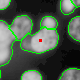
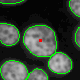
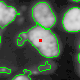
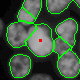
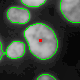
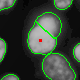
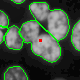
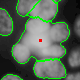
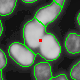
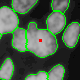

In [9]:
# Find large nuclei outliers for the current plate
nuclei_clustered_thresholds = {
    "Nuclei_Intensity_MassDisplacement_DNA": 1.8,
    "Nuclei_Intensity_IntegratedIntensity_DNA": 1.5,
}

nuclei_clustered_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=nuclei_clustered_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    nuclei_clustered_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(nuclei_clustered_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/SK-N-AS_repo1_screen/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping,
        display_options={
            "brightness": 1,
            "offset_bounding_box": {
                "x_min": -40,
                "y_min": -40,
                "x_max": 40,
                "y_max": 40,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Nuclei_Intensity_MassDisplacement_DNA",
            "Nuclei_Intensity_IntegratedIntensity_DNA",
        ]
    ]

    print(nuclei_clustered_outliers_cdf.shape)
    display(
        nuclei_clustered_outliers_cdf.sort_values(
            by="Nuclei_Intensity_MassDisplacement_DNA", ascending=True
        ).head(10).T
    )
    # nuclei_clustered_outliers_cdf.sample(n=2, random_state=0)


Number of outliers: 63127 (2.90%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.44518272425249167
Nuclei_AreaShape_Solidity Max: 0.9061611374407583
(63127, 2)


,372492,183021,285341,492921,60008,171740,85397,119727,186166,500485
Image_FileName_OrigDNA,,,,,,,,,,
Nuclei_AreaShape_Solidity,0.445183,0.46729,0.473118,0.488235,0.490099,0.511905,0.523677,0.526066,0.534091,0.536585

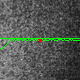
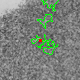
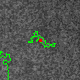
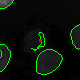
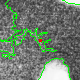
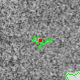
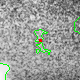
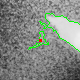
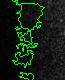
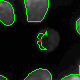

In [10]:
# Find low nuclei solidity outliers for the current plate
missegmented_nuclei_thresholds = {
    "Nuclei_AreaShape_Solidity": -2.5,
}

solidity_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=missegmented_nuclei_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    solidity_nuclei_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(solidity_nuclei_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/SK-N-AS_repo1_screen/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping,
        display_options={
            "brightness": 1,
            "offset_bounding_box": {
                "x_min": -40,
                "y_min": -40,
                "x_max": 40,
                "y_max": 40,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Nuclei_AreaShape_Solidity",
        ]
    ]

    print(solidity_nuclei_outliers_cdf.shape)
    display(
        solidity_nuclei_outliers_cdf.sort_values(
            by="Nuclei_AreaShape_Solidity", ascending=True
        ).head(10).T
    )
    # solidity_nuclei_outliers_cdf.sample(n=5)


Number of outliers: 18779 (0.86%)
Outliers Range:
Nuclei_Intensity_IntegratedIntensity_DNA Min: 0.43576226430013776
Nuclei_Intensity_IntegratedIntensity_DNA Max: 8.827637575566769
(18779, 2)


,1649769,2090322,348131,175991,142865,105628,976801,233317,320859,1901258
Image_FileName_OrigDNA,,,,,,,,,,
Nuclei_Intensity_IntegratedIntensity_DNA,8.827638,8.826749,8.826626,8.826198,8.825728,8.825722,8.82563,8.825386,8.825238,8.825221

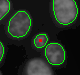
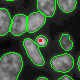
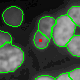
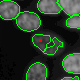
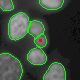
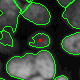
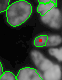
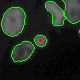
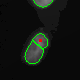
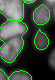

In [11]:
# Find background segmented as nuclei outliers for the current plate
background_segmentation_thresholds = {
    "Nuclei_Intensity_IntegratedIntensity_DNA": -1.5,
}

background_segmentation_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=background_segmentation_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    background_segmentation_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(background_segmentation_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/SK-N-AS_repo1_screen/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping,
        display_options={
            "brightness": 1,
            "offset_bounding_box": {
                "x_min": -40,
                "y_min": -40,
                "x_max": 40,
                "y_max": 40,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Nuclei_Intensity_IntegratedIntensity_DNA",
        ]
    ]

    print(background_segmentation_outliers_cdf.shape)
    display(
        background_segmentation_outliers_cdf.sort_values(
            by="Nuclei_Intensity_IntegratedIntensity_DNA", ascending=False
        ).head(10).T
    )
    # background_segmentation_outliers_cdf.sample(n=2, random_state=0)


## Run QC with `cell` features

In [12]:
# Set the compartment of choice to perform QC at the start (will change later)
compartment = "Cells"

# create an outline and orig mapping dictionary to map original images to outlines
# note: we turn off formatting here to avoid the key-value pairing definition
# from being reformatted by black, which is normally preferred.
# fmt: off
outline_to_orig_mapping_cells = {
    rf"{compartment}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": 
    rf"r{int(record['Image_Metadata_Row']):02d}c{int(record['Image_Metadata_Col']):02d}f{int(record['Image_Metadata_Site']):02d}p(\d{{2}})-ch\d+sk\d+fk\d+fl\d+\.tiff"
    for record in plate_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Image_Metadata_Row",
            "Image_Metadata_Col",
        ]
    ].to_dict(orient="records")
}
# fmt: on

next(iter(outline_to_orig_mapping_cells.items()))


('CellsOutlines_BR00148920_L08_9.tiff',
 'r12c08f09p(\\d{2})-ch\\d+sk\\d+fk\\d+fl\\d+\\.tiff')

Number of outliers: 41851 (1.92%)
Outliers Range:
Cells_Intensity_IntegratedIntensity_DNA Min: 88.8355590896681
Cells_Intensity_IntegratedIntensity_DNA Max: 3363.671350170858
(41851, 3)


,1028339,372270,483817,1403767,183098
Image_FileName_OrigDNA,,,,,
Image_FileName_OrigAGP,,,,,
Cells_Intensity_IntegratedIntensity_DNA,3363.67135,2748.598975,2210.703562,2177.544513,2079.648216

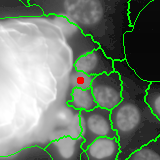
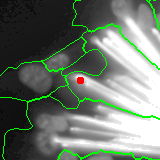
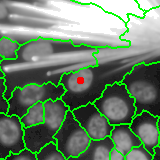
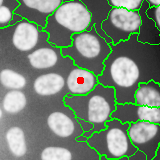
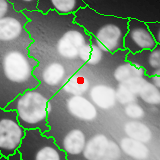
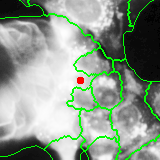
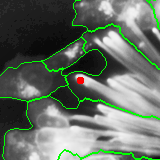
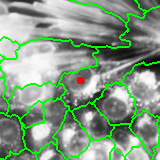
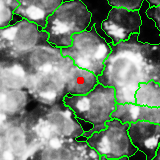
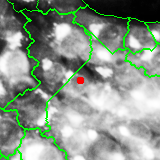

In [13]:
# Find cell outliers for the current plate
cell_outliers_thresholds = {
    # Set low to attempt to detect all instances of abnormally high int in nuclei for whole cells
    "Cells_Intensity_IntegratedIntensity_DNA": 2.5,
}

cell_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=cell_outliers_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    cell_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(cell_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/SK-N-AS_repo1_screen/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping_cells,
        display_options={
            "center_dot": True,
            "brightness": 25,
            "offset_bounding_box": {
                "x_min": -80,
                "y_min": -80,
                "x_max": 80,
                "y_max": 80,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Image_FileName_OrigAGP",
            "Cells_Intensity_IntegratedIntensity_DNA",
        ]
    ]

    print(cell_outliers_cdf.shape)
    display(
        cell_outliers_cdf.sort_values(
            by="Cells_Intensity_IntegratedIntensity_DNA", ascending=False
        ).head(5).T
    )
    # cell_outliers_cdf.sample(n=5, random_state=0)


## Save annotations file for plate with QC flags

In [14]:
# Use label outliers to export qc.parquet file per plate

# Combine every QC condition defined above into one set of named thresholds
qc_feature_thresholds = {
    "nuclei_clustered": nuclei_clustered_thresholds,
    "missegmented_nuclei": missegmented_nuclei_thresholds,
    "background_segmentation": background_segmentation_thresholds,
    "cell_outliers": cell_outliers_thresholds,
}

# export_as_annotations=True keeps only metadata_columns + the generated
# Metadata_cqc_*_is_outlier flags
qc_annotations = label_outliers(
    df=plate_df,
    feature_thresholds=qc_feature_thresholds,
    export_path=str(cleaned_dir / f"{plate_id}_qc_annotations.parquet"),
    export_as_annotations=True,
    annotation_metadata_columns=metadata_columns,
)

# Print the number of outliers and percentage of outliers for each QC condition
qc_annotations.filter(like="Metadata_cqc_").sum().to_frame(name="num_outliers").assign(
    percentage_outliers=lambda x: (x["num_outliers"] / len(qc_annotations)) * 100
)


,num_outliers,percentage_outliers
Metadata_cqc_nuclei_clustered_is_outlier,32402,1.486008
Metadata_cqc_missegmented_nuclei_is_outlier,63127,2.895106
Metadata_cqc_background_segmentation_is_outlier,18779,0.861235
Metadata_cqc_cell_outliers_is_outlier,41851,1.919354
